In [1]:
# ============================================================
# Notebook 06 — XGBoost Modelling
# Baseline V1: Simple lag features (1, 2, 3, 12 months)
# Reference: Chen & Guestrin (2016)
# Implementation: xgboost library
# Author: Nihaar Raut | 001309432
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

PROCESSED = Path('../data/processed')
FIGURES = Path('../outputs/figures')

# Load all four series
ndvi_amazon_train = pd.read_csv(PROCESSED / 'ndvi_amazon_train.csv', parse_dates=['date'])
ndvi_amazon_test = pd.read_csv(PROCESSED / 'ndvi_amazon_test.csv', parse_dates=['date'])

ndvi_sahel_train = pd.read_csv(PROCESSED / 'ndvi_sahel_train.csv', parse_dates=['date'])
ndvi_sahel_test = pd.read_csv(PROCESSED / 'ndvi_sahel_test.csv', parse_dates=['date'])

sst_atlantic_train = pd.read_csv(PROCESSED / 'sst_atlantic_train.csv', parse_dates=['date'])
sst_atlantic_test = pd.read_csv(PROCESSED / 'sst_atlantic_test.csv', parse_dates=['date'])

sst_indian_train = pd.read_csv(PROCESSED / 'sst_indian_train.csv', parse_dates=['date'])
sst_indian_test = pd.read_csv(PROCESSED / 'sst_indian_test.csv', parse_dates=['date'])

print("All series loaded successfully")

All series loaded successfully


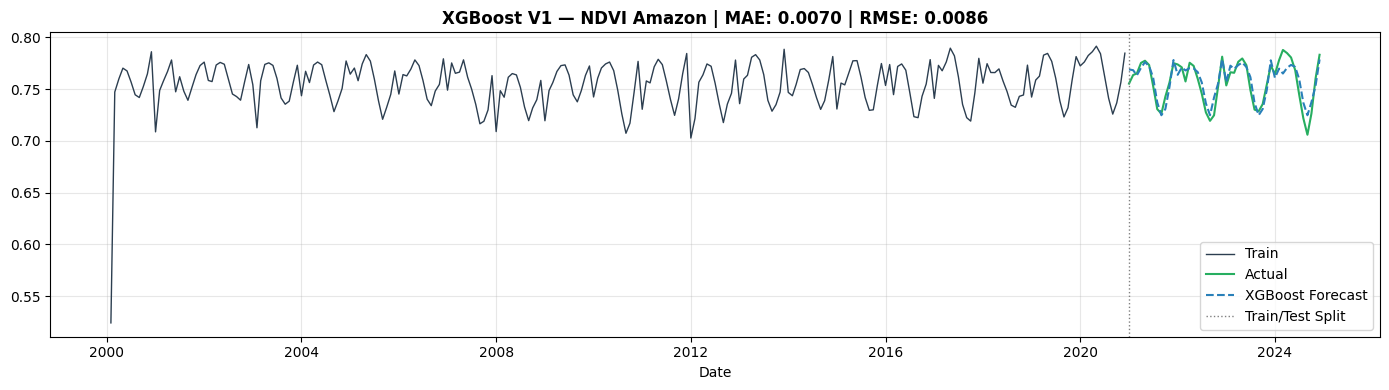

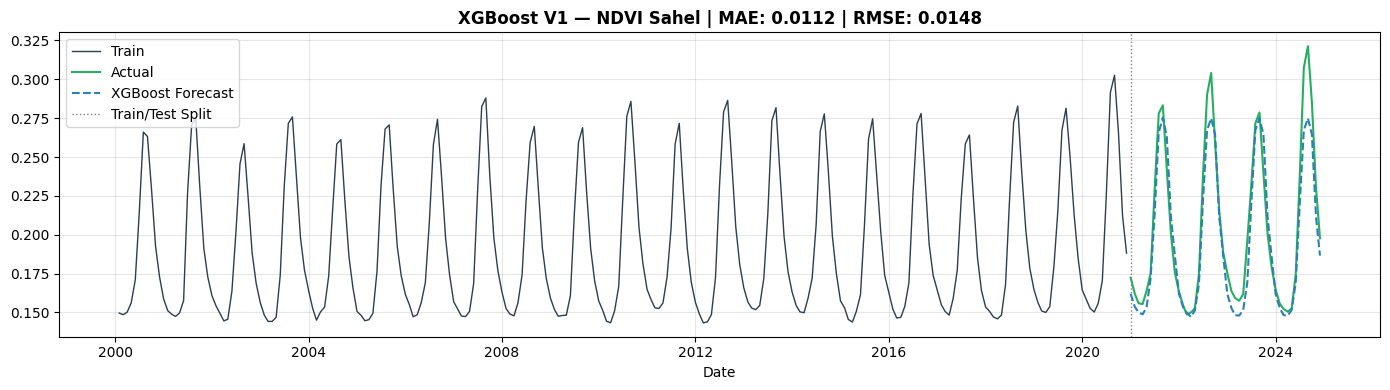

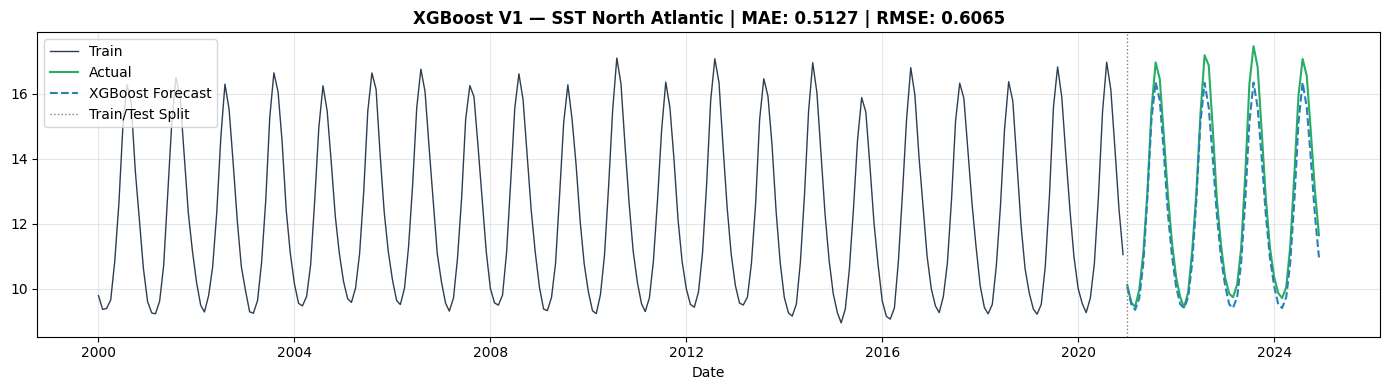

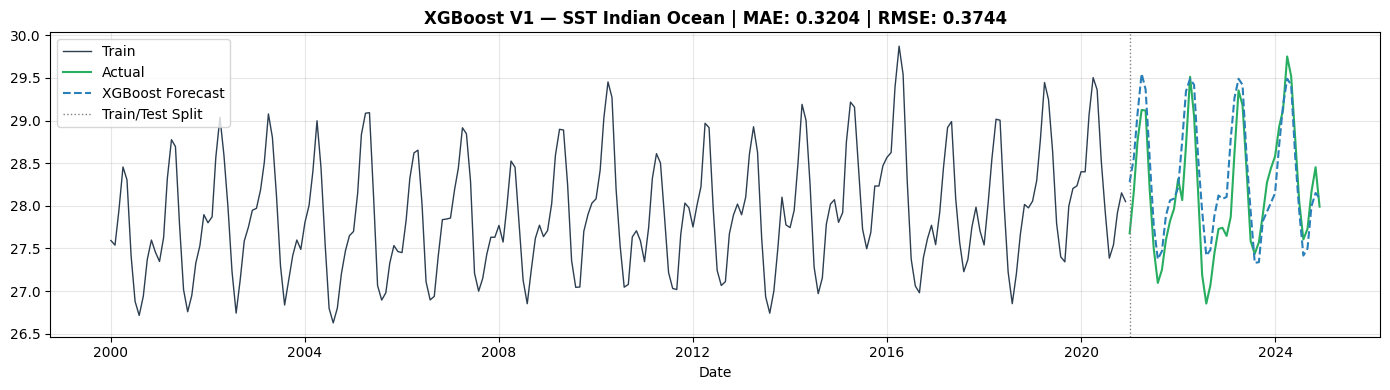


=== XGBoost V1 Baseline Results ===
            series    MAE   RMSE
       NDVI Amazon 0.0070 0.0086
        NDVI Sahel 0.0112 0.0148
SST North Atlantic 0.5127 0.6065
  SST Indian Ocean 0.3204 0.3744


In [2]:
# ============================================================
# XGBoost V1 — Baseline with simple lag features
# Lags: 1, 2, 3, 12 months + month of year
# No native time awareness — time encoded via features
# Recursive forecasting for multi-step ahead prediction
# ============================================================

def create_lag_features(df, value_col, lags=[1, 2, 3, 12]):
    df = df.copy()
    for lag in lags:
        df[f'lag_{lag}'] = df[value_col].shift(lag)
    df['month'] = df['date'].dt.month
    df = df.dropna()
    return df

def run_xgboost(train, test, value_col, series_name, lags=[1, 2, 3, 12]):
    # Combine train and test for feature creation
    full = pd.concat([train, test]).reset_index(drop=True)
    full = create_lag_features(full, value_col, lags)
    
    feature_cols = [f'lag_{l}' for l in lags] + ['month']
    
    # Split back after feature creation
    train_feat = full[full['date'] <= train['date'].max()]
    test_feat = full[full['date'] >= test['date'].min()]
    
    X_train = train_feat[feature_cols]
    y_train = train_feat[value_col]
    X_test = test_feat[feature_cols]
    actual = test_feat[value_col].values
    
    # Fit model
    model = XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42,
        verbosity=0
    )
    model.fit(X_train, y_train)
    
    # Recursive forecasting
    forecast = []
    history = list(train[value_col].values)
    
    for i in range(len(test)):
        row = {}
        for lag in lags:
            row[f'lag_{lag}'] = history[-lag] if lag <= len(history) else history[0]
        row['month'] = test['date'].iloc[i].month
        pred = model.predict(pd.DataFrame([row]))[0]
        forecast.append(pred)
        history.append(pred)
    
    forecast = np.array(forecast)
    
    # Metrics
    mae = mean_absolute_error(actual, forecast)
    rmse = np.sqrt(mean_squared_error(actual, forecast))
    
    # Plot
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(train['date'], train[value_col],
            color='#2c3e50', linewidth=1, label='Train')
    ax.plot(test['date'], actual,
            color='#27ae60', linewidth=1.5, label='Actual')
    ax.plot(test['date'], forecast,
            color='#2980b9', linewidth=1.5, linestyle='--', label='XGBoost Forecast')
    ax.axvline(x=test['date'].iloc[0], color='grey',
               linestyle=':', linewidth=1, label='Train/Test Split')
    ax.set_title(f'XGBoost V1 — {series_name} | MAE: {mae:.4f} | RMSE: {rmse:.4f}',
                 fontweight='bold')
    ax.set_xlabel('Date')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    
    filename = f"fig_xgboost_v1_{series_name.lower().replace(' ', '_')}.png"
    plt.savefig(FIGURES / filename, dpi=150, bbox_inches='tight')
    plt.show()
    
    return {'series': series_name, 'MAE': round(mae, 4), 'RMSE': round(rmse, 4)}

# Run V1 on all four series
results = []

results.append(run_xgboost(ndvi_amazon_train, ndvi_amazon_test,
                            'ndvi_mean', 'NDVI Amazon'))

results.append(run_xgboost(ndvi_sahel_train, ndvi_sahel_test,
                            'ndvi_mean', 'NDVI Sahel'))

results.append(run_xgboost(sst_atlantic_train, sst_atlantic_test,
                            'sst_mean', 'SST North Atlantic'))

results.append(run_xgboost(sst_indian_train, sst_indian_test,
                            'sst_mean', 'SST Indian Ocean'))

# Results table
results_df = pd.DataFrame(results)
print("\n=== XGBoost V1 Baseline Results ===")
print(results_df.to_string(index=False))